## Peramalan kadar $NO_2$ di daerah Bangkalan Madura

**Latar Belakang**

Kualitas udara merupakan salah satu faktor penting yang memengaruhi kesehatan manusia dan kelestarian lingkungan. Seiring meningkatnya aktivitas transportasi, industri, serta pertumbuhan penduduk, tingkat pencemaran udara di berbagai wilayah juga mengalami peningkatan. Salah satu polutan udara yang banyak menjadi perhatian adalah Nitrogen Dioksida ($NO_2$), yaitu gas yang dihasilkan dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan aktivitas industri.

Paparan gas $NO_2$ dalam konsentrasi tinggi dapat memberikan dampak negatif terhadap kesehatan, terutama pada sistem pernapasan. Selain itu, keberadaan $NO_2$ juga berkontribusi terhadap pembentukan hujan asam serta penurunan kualitas lingkungan. Oleh karena itu, pemantauan dan analisis kadar $NO_2$ menjadi hal yang penting untuk dilakukan sebagai upaya dalam memahami kondisi kualitas udara suatu wilayah.

Pada penelitian ini dilakukan analisis data time series kadar $NO_2$ di wilayah Bangkalan, Madura menggunakan data satelit Sentinel-5P yang diperoleh dari Copernicus Data Space Ecosystem. Data yang digunakan mencakup periode pengamatan dari Oktober 2023 hingga September 2025. Sebelum dilakukan pemodelan, data terlebih dahulu melalui tahap preprocessing seperti penanganan missing value, deteksi outlier, dan normalisasi data.

Selanjutnya dilakukan pemodelan menggunakan metode K-Nearest Neighbor (KNN) Regression untuk memprediksi nilai kadar $NO_2$ berdasarkan data historis sebelumnya. Dengan adanya pemodelan ini diharapkan dapat memberikan gambaran mengenai pola perubahan kadar $NO_2$ serta mengevaluasi kemampuan metode KNN Regression dalam melakukan prediksi pada data kualitas udara.


**1.Pengumpulan Data**

Tahap pertama yang dilakukan adalah mengumpulkan data time series harian kadar $NO_2$ pada wilayah Bangkalan, Madura. Data diperoleh dari platform Copernicus Data Space Ecosystem yang menyediakan berbagai data pengamatan bumi berbasis satelit.

Sebelum melakukan pengambilan data, pengguna harus membuat akun terlebih dahulu pada website Copernicus Data Space melalui:

https://dataspace.copernicus.eu/

Setelah akun berhasil dibuat dan proses login selesai, pengguna dapat mengakses dokumentasi resmi yang menjelaskan cara pengambilan data menggunakan OpenEO pada tautan berikut:

https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

Proses pengambilan data dilakukan menggunakan bahasa pemrograman Python melalui layanan JupyterLab yang telah disediakan oleh Copernicus. Untuk mengaksesnya, buka halaman:

https://dataspace.copernicus.eu/analyse/jupyterlab

Kemudian pilih Access JupyterLab, tunggu hingga lingkungan kerja berhasil dimuat, lalu pilih kernel Python 3 (ipykernel) sebagai media untuk menjalankan kode program.

Pada penelitian ini, data yang diambil merupakan data konsentrasi gas $NO_2$ pada wilayah Bangkalan dengan rentang waktu pengamatan mulai 1 Oktober 2023 hingga 1 Oktober 2025. Data tersebut diperoleh dari satelit Sentinel-5P yang menyediakan informasi kualitas udara secara berkala.

Sebelum melakukan koneksi ke server Copernicus, terlebih dahulu dilakukan instalasi pustaka OpenEO menggunakan perintah berikut:

In [1]:
pip install openeo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Lalu tuliskan code dibawah:

pada saat menjalankan baris code diatas (connection), nanti akan diminta authentikasi seperti output berikut:

Terminal/Output
Visit (link authentikasi) 📋 to authenticate.
✅ Authorized successfully
Authenticated using device code flow.

In [2]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=CLGI-NEAQ 📋 to authenticate.

[###################################--] ⌛ Authorization pending

KeyboardInterrupt: 

klik link authentikasi lalu login menggunakan akun “copernicus” kalian.

In [5]:
import openeo

connection = openeo.connect(
    "openeo.dataspace.copernicus.eu"
).authenticate_oidc()

aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.67096863805529, -6.8895513729466415],
            [113.00665268043338, -6.889564998138226],
            [113.00655832619032, -7.171490698434624],
            [112.6709688563065, -7.171550110786541],
            [112.67096863805529, -6.8895513729466415]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.67096863805529,
        "south": -7.171550110786541,
        "east": 113.00665268043338,
        "north": -6.8895513729466415
    },
    bands=["NO2"],
)

# rata-rata per hari
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# rata-rata area
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

# download data
job = s5post.execute_batch(
    title="NO2_Bangkalan",
    outputfile="NO2Bangkalan.nc"
)

Authenticated using refresh token.
0:00:00 Job 'j-260603022248483fbca926b4b2ee73a2': send 'start'
0:00:11 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:16 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:23 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:31 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:40 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:53 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:01:08 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:01:28 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:01:52 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:02:22 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:03:00 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:03:46 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:04:45 Job 'j-260603022248483fbca926b4b

setelah berhasil melakukan autentikasi, langkah berikutnya adalah menentukan Area of Interest (AOI) atau wilayah yang akan digunakan sebagai lokasi pengambilan data. Pada penelitian ini, wilayah yang dipilih adalah daerah Bangkalan, Madura.

Untuk memperoleh koordinat wilayah penelitian, digunakan website:

https://geojson.io/

 Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.


 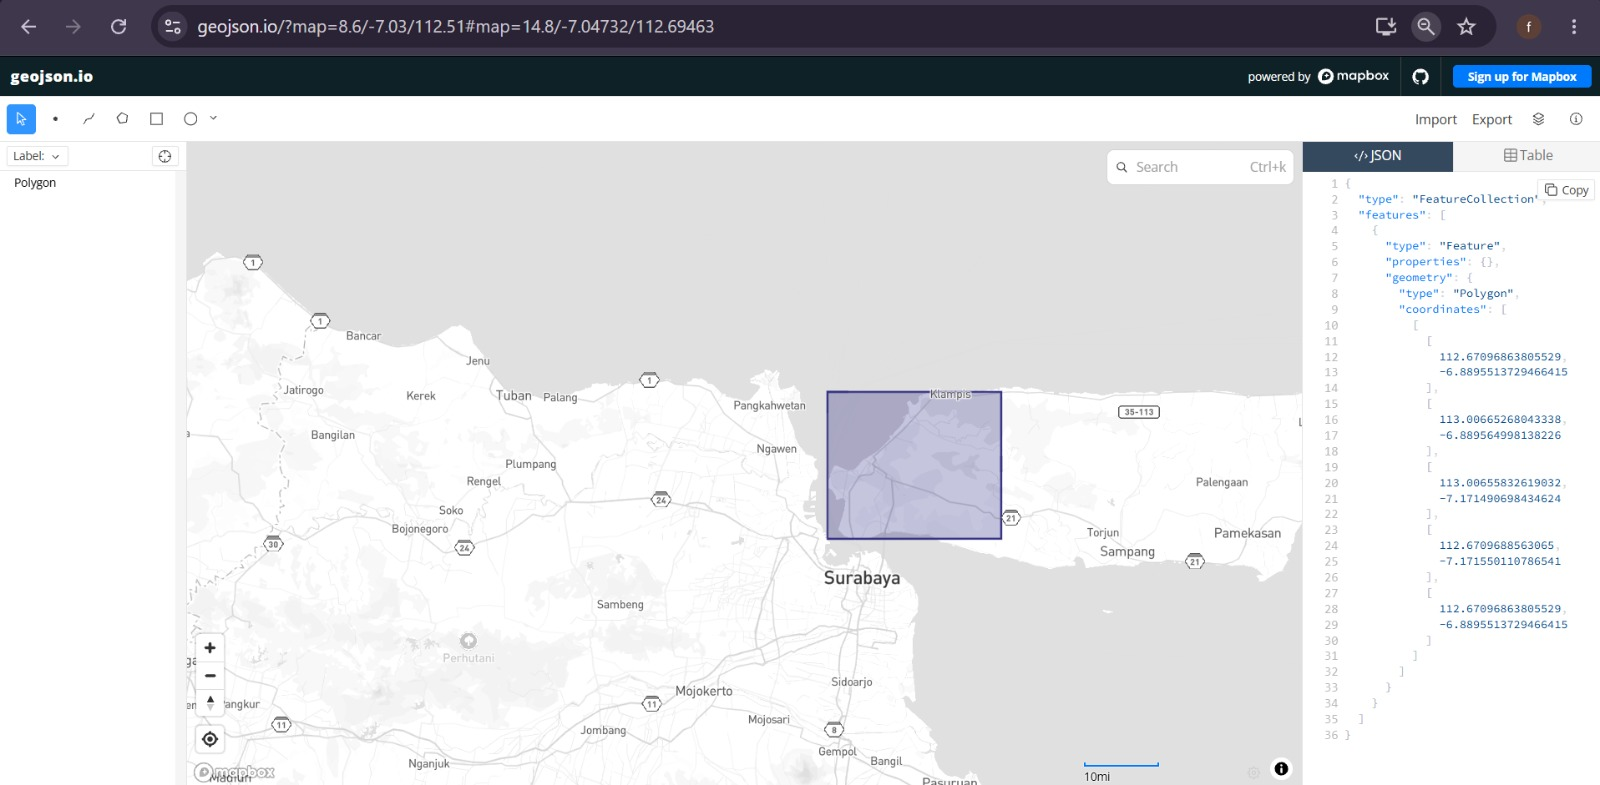

Setelah koordinat wilayah berhasil ditentukan, tambahkan kode berikut untuk memulai proses pengambilan data dan menyimpannya dalam format NetCDF (.nc).




In [ ]:
job = s5post.execute_batch(
    title="NO2_Bangkalan",
    outputfile="NO2Bangkalan.nc"
)

Tunggu proses pengambilan data, output proses seperti berikut:

In [ ]:
Authenticated using refresh token.
0:00:00 Job 'j-260603022248483fbca926b4b2ee73a2': send 'start'
0:00:11 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:16 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:23 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:31 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:40 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:00:53 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:01:08 Job 'j-260603022248483fbca926b4b2ee73a2': queued (progress 0%)
0:01:28 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:01:52 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:02:22 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:03:00 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:03:46 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:04:45 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:05:45 Job 'j-260603022248483fbca926b4b2ee73a2': running (progress N/A)
0:06:45 Job 'j-260603022248483fbca926b4b2ee73a2': finished (progress 100%)

Abaikan ketika ada N/A.

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2 . Disitu terdapat nama dataset dan status pengambilan data.

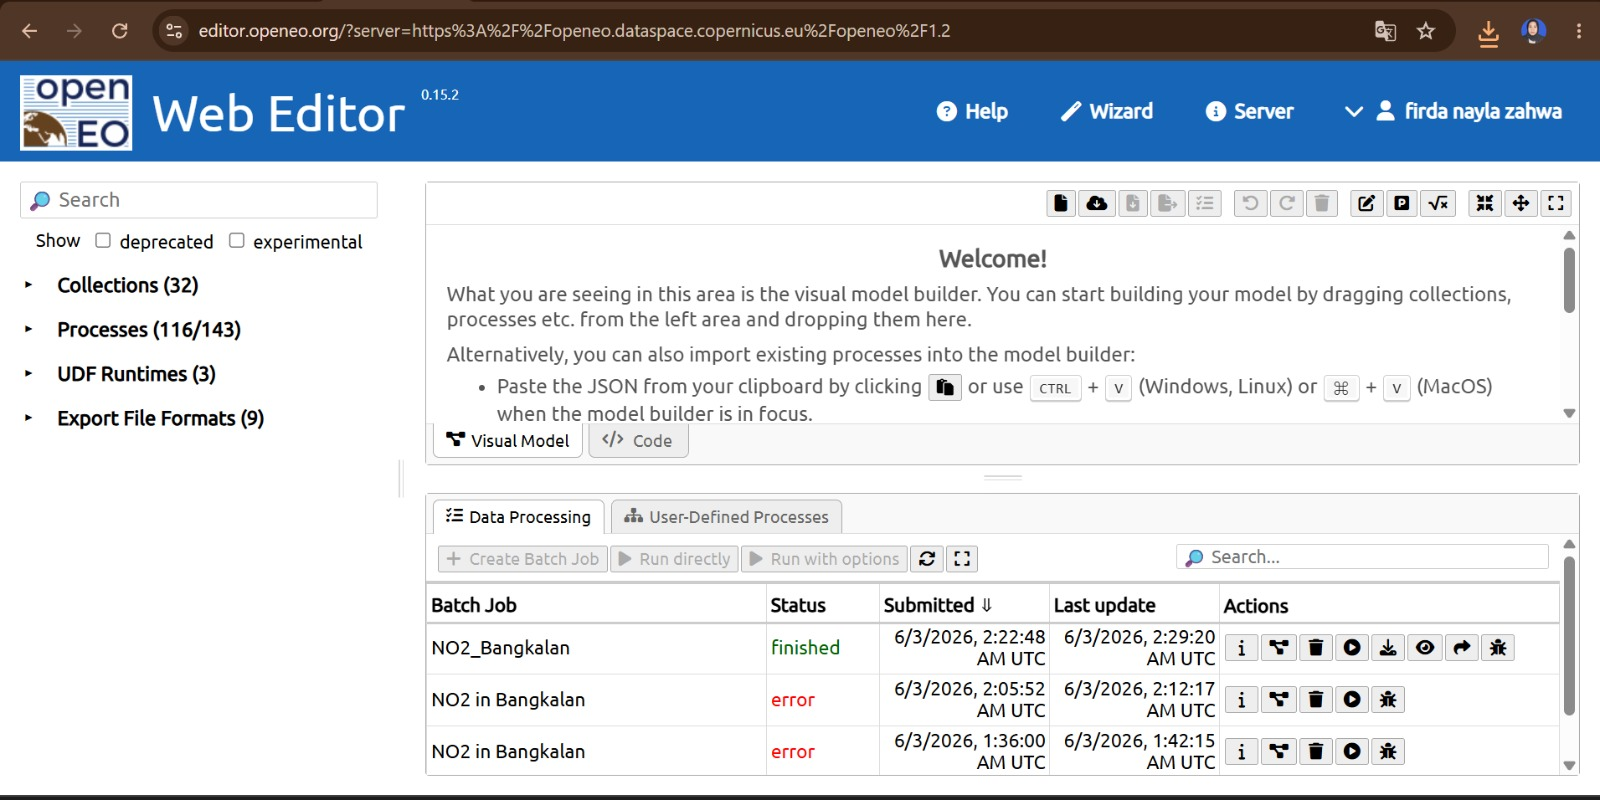

**2.Prepoccessing Data**

Setelah data berhasil diunduh, file yang diperoleh masih berbentuk NetCDF (.nc). Oleh karena itu, perlu dilakukan preprocessing untuk mengambil data NO₂ dan mengubah data waktu menjadi format tanggal.

In [4]:
!pip install netCDF4

import netCDF4

file_path = "openEO.nc"

ds = netCDF4.Dataset(file_path)

print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

print(type(no2))
print(len(no2))
print(len(no2[0]))
print(len(no2[0][0]))
print(no2[0][0][0])

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
725
9
7
3.7701793e-05


ari output diatas diketahui bahwa data NO₂ memiliki 725 record dan bertipe MaskedArray. Setiap record memiliki ukuran grid 9 × 7 yang merepresentasikan area pengamatan.

Jadi struktur data NO₂ per record adalah:

In [ ]:
[
    [[] * 7] * 9
]

Karena dalam satu hari terdapat banyak nilai NO₂ pada setiap grid, maka data perlu diolah lebih lanjut agar diperoleh satu nilai representatif untuk setiap tanggal pengamatan.

a.Mengatasi Missing Value menggunakan metode Interpolasi Linear

Pada data NO₂ masih terdapat nilai yang hilang (missing value). Oleh karena itu dilakukan interpolasi linear untuk mengisi nilai yang kosong berdasarkan nilai sebelum dan sesudahnya.

In [5]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)

# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(
            method='linear',
            limit_direction='both'
        ).to_numpy()

Kode diatas digunakan untuk mengisi nilai yang hilang (missing value) pada data NO₂ menggunakan metode Interpolasi Linear. Proses dilakukan pada setiap grid pengamatan sehingga nilai yang kosong dapat diperkirakan berdasarkan nilai sebelum dan sesudahnya.

b. Rata-rata kan Data dan ubah Datetime

Karena dalam satu hari terdapat beberapa nilai NO₂ pada berbagai grid pengamatan, maka dilakukan proses rata-rata agar setiap tanggal hanya memiliki satu nilai NO₂. Selain itu, data waktu diubah ke format YYYY-MM-DD agar lebih mudah digunakan pada proses analisis selanjutnya.

In [6]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

Kode diatas menghasilkan dua variabel baru, yaitu:


- new_dates : berisi tanggal pengamatan yang sudah dalam format YYYY-MM-DD.

- new_no2 : berisi nilai rata-rata kadar NO₂ untuk setiap tanggal pengamatan.

Dengan proses ini, setiap tanggal hanya memiliki satu nilai NO₂ sehingga data lebih mudah diolah pada tahap berikutnya.

c. Simpan data dalam bentuk CSV

Setelah data berhasil dirata-ratakan, data disimpan ke dalam format CSV agar lebih mudah digunakan pada proses analisis dan pemodelan.

In [7]:
import pandas as pd

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Bangkalan_timeseries.csv", index=False)

Kode diatas akan menghasilkan file NO2_Bangkalan_timeseries.csv yang berisi dua kolom, yaitu tanggal pengamatan (date) dan nilai rata-rata kadar NO₂.

d. Pengecekan Missing Value data harian pada CSV

Setelah data disimpan dalam format CSV, langkah berikutnya adalah memeriksa apakah terdapat tanggal yang hilang pada rentang waktu pengamatan. Pengecekan dilakukan dengan membandingkan tanggal yang tersedia pada dataset dengan rentang tanggal lengkap dari 1 Oktober 2023 sampai 30 September 2025.

In [8]:
import pandas as pd

df = pd.read_csv("NO2_Bangkalan_timeseries.csv")

# Pastikan kolom date bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"

full_range = pd.date_range(
    start=start_date,
    end=end_date,
    freq='D'
)

# Cari tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 6
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


In [13]:
print(df.columns)
print(df.head())

Index(['NO2'], dtype='object')
                 NO2
date                
2023-10-01  0.000029
2023-10-02  0.000025
2023-10-03  0.000027
2023-10-04  0.000024
2023-10-05  0.000023


In [14]:
import pandas as pd

df = pd.read_csv("NO2_Bangkalan_timeseries.csv")

print(df.columns)
print(df.head())

Index(['date', 'NO2'], dtype='object')
         date       NO2
0  2023-10-01  0.000029
1  2023-10-02  0.000025
2  2023-10-03  0.000027
3  2023-10-04  0.000024
4  2023-10-05  0.000023


Karena masih terdapat tanggal yang hilang, maka dilakukan proses interpolasi linear kembali pada data harian agar seluruh tanggal dalam rentang pengamatan memiliki nilai NO₂.

In [15]:
# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# Jika masih ada NaN di awal/akhir
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_6058/407801984.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


Setelah proses interpolasi selesai, data disimpan kembali ke dalam file no2_timeseries_interpolated.csv. Selanjutnya dilakukan pengecekan ulang untuk memastikan tidak ada lagi tanggal yang hilang pada dataset.

In [16]:
import pandas as pd

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

full_range = pd.date_range(
    start="2023-10-01",
    end="2025-09-30",
    freq='D'
)

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

print(df.head())
print(df.info())

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
        date       NO2
0 2023-10-01  0.000029
1 2023-10-02  0.000025
2 2023-10-03  0.000027
3 2023-10-04  0.000024
4 2023-10-05  0.000023
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    731 non-null    datetime64[ns]
 1   NO2     731 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.6 KB
None


Berdasarkan hasil tersebut, seluruh missing value berhasil diperbaiki sehingga dataset memiliki 731 data harian tanpa tanggal yang hilang. Dengan demikian data telah siap digunakan pada tahap deteksi outlier dan pemodelan.

e. Deteksi Outlier IQR

Setelah seluruh missing value berhasil diperbaiki, langkah berikutnya adalah mendeteksi data outlier menggunakan metode Interquartile Range (IQR). Metode ini digunakan untuk menemukan nilai yang berada jauh di luar rentang data normal.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 15
         date       NO2
38 2023-11-08  0.000045
39 2023-11-09  0.000047
45 2023-11-15  0.000058
46 2023-11-16  0.000047
48 2023-11-18  0.000057


Berdasarkan hasil perhitungan IQR diperoleh sebanyak 15 data outlier pada dataset NO₂.

Untuk melihat posisi outlier pada data time series, dilakukan visualisasi menggunakan grafik garis. Titik berwarna merah menunjukkan data yang terdeteksi sebagai outlier, sedangkan garis putus-putus menunjukkan batas bawah (lower bound) dan batas atas (upper bound) berdasarkan metode IQR.

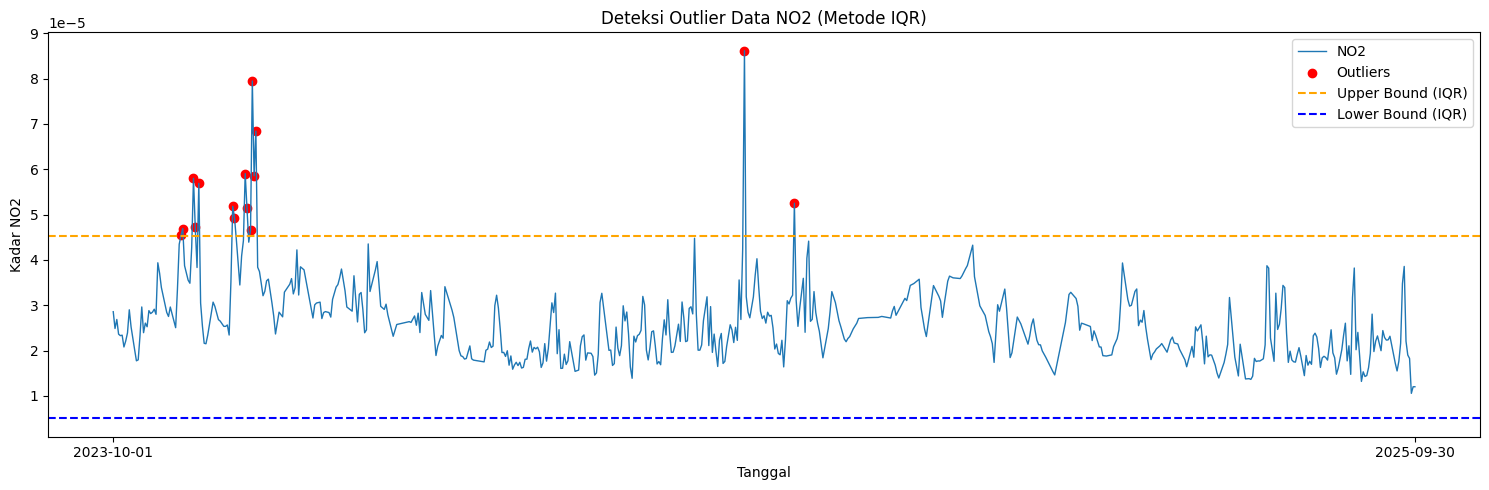

In [18]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(
    outliers_iqr['date'],
    outliers_iqr['NO2'],
    color='red',
    marker='o',
    label="Outliers"
)

# Garis batas atas & bawah
plt.axhline(
    upper_bound,
    color='orange',
    linestyle='dashed',
    label="Upper Bound (IQR)"
)

plt.axhline(
    lower_bound,
    color='blue',
    linestyle='dashed',
    label="Lower Bound (IQR)"
)

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[
        df['date'].iloc[0].strftime('%Y-%m-%d'),
        df['date'].iloc[-1].strftime('%Y-%m-%d')
    ]
)

plt.show()

Dari grafik di atas terlihat bahwa beberapa nilai NO₂ berada di luar batas atas IQR sehingga terdeteksi sebagai outlier. Data outlier tersebut akan diperbaiki pada tahap berikutnya agar tidak mempengaruhi proses pemodelan.

Setelah outlier berhasil dideteksi, nilai outlier tersebut tidak langsung dihapus dari dataset. Karena data yang digunakan merupakan data time series, maka nilai outlier terlebih dahulu diubah menjadi NaN dan kemudian diisi kembali menggunakan metode Interpolasi Linear agar pola data tetap terjaga.

In [19]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask(
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
)

print("Jumlah nilai yang dinyatakan sebagai outlier:",
      df['NO2_cleaned'].isna().sum())

# Interpolasi linear
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Isi jika masih ada NaN
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

print("Jumlah missing setelah interpolasi:",
      df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 15
Jumlah missing setelah interpolasi: 0


Berdasarkan hasil di atas, terdapat 15 data outlier yang berhasil terdeteksi dan diubah menjadi nilai kosong (NaN). Setelah dilakukan interpolasi linear, seluruh nilai kosong berhasil diperbaiki sehingga tidak terdapat missing value pada dataset.

Untuk melihat hasil perbaikan data setelah proses penghapusan outlier dan interpolasi, dilakukan visualisasi menggunakan grafik time series berikut.

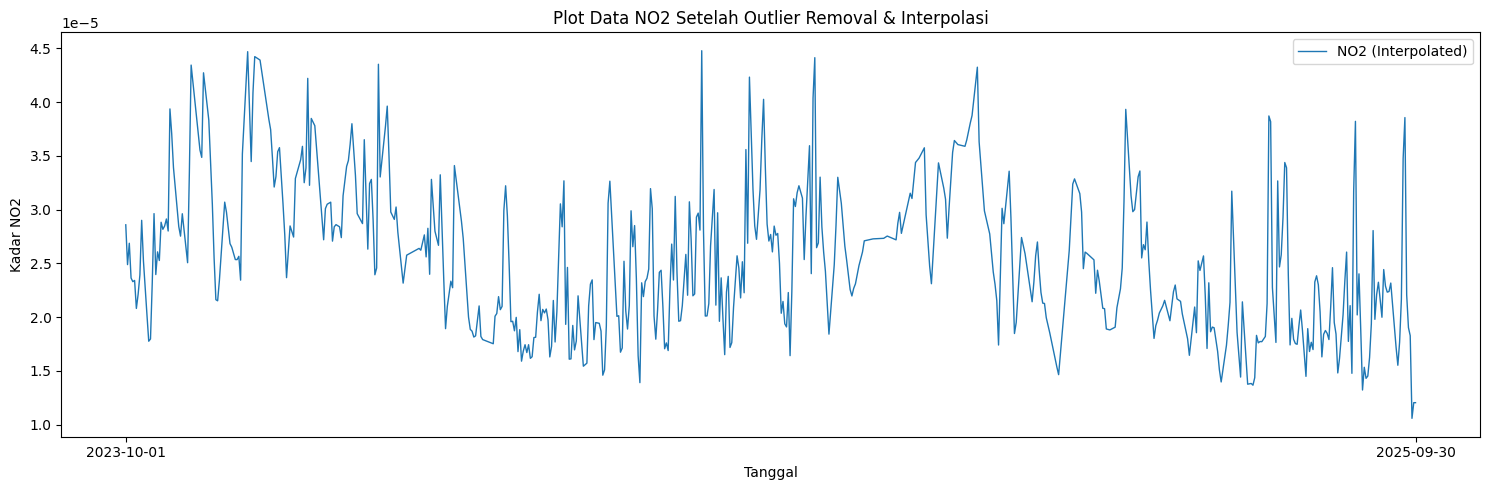

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    df['date'],
    df['NO2_filled'],
    label="NO2 (Interpolated)",
    linewidth=1
)

plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[
        df['date'].iloc[0].strftime('%Y-%m-%d'),
        df['date'].iloc[-1].strftime('%Y-%m-%d')
    ]
)

plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

Dari grafik tersebut terlihat bahwa data telah menjadi lebih stabil karena nilai-nilai ekstrem yang terdeteksi sebagai outlier telah diperbaiki menggunakan interpolasi linear. Dataset hasil preprocessing ini kemudian digunakan pada tahap pemodelan menggunakan algoritma KNN Regression.

**3. Modeling menggunakan KNN Regression**

a. Uji Korelasi Data

Sebelum membangun model KNN Regression, dilakukan uji korelasi untuk mengetahui hubungan antara data NO₂ pada hari sebelumnya dengan data NO₂ pada hari yang akan diprediksi. Pada tahap ini digunakan data historis hingga 30 hari sebelumnya (lag 30).

Data kemudian diubah ke bentuk supervised learning, dimana setiap kolom merepresentasikan nilai NO₂ pada hari-hari sebelumnya dan satu kolom target yaitu nilai NO₂ pada hari saat ini.

In [22]:
print(df.columns)

Index(['date', 'NO2', 'NO2_cleaned', 'NO2_filled'], dtype='object')


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(
    df[['NO2_filled']]
)

print(df.head())
print(df.columns)

        date       NO2  NO2_cleaned  NO2_filled  NO2_scaled
0 2023-10-01  0.000029     0.000029    0.000029    0.526417
1 2023-10-02  0.000025     0.000025    0.000025    0.418170
2 2023-10-03  0.000027     0.000027    0.000027    0.476255
3 2023-10-04  0.000024     0.000024    0.000024    0.381712
4 2023-10-05  0.000023     0.000023    0.000023    0.371799
Index(['date', 'NO2', 'NO2_cleaned', 'NO2_filled', 'NO2_scaled'], dtype='object')


Hasil korelasi yang diperoleh adalah sebagai berikut:

In [24]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    df_supervised['NO2(t)'] = data

    df_supervised.dropna(inplace=True)

    return df_supervised

# buat data 30 hari sebelumnya
supervised_df30 = create_supervised(
    df['NO2_scaled'],
    n_lag=30
)

# hitung korelasi
lag_cols = supervised_df30.drop(columns="NO2(t)").columns

correlations = supervised_df30[lag_cols].corrwith(
    supervised_df30['NO2(t)']
)

print(correlations)

NO2(t-30)    0.437949
NO2(t-29)    0.458464
NO2(t-28)    0.455574
NO2(t-27)    0.425754
NO2(t-26)    0.391428
NO2(t-25)    0.370403
NO2(t-24)    0.344188
NO2(t-23)    0.342316
NO2(t-22)    0.353127
NO2(t-21)    0.352365
NO2(t-20)    0.342040
NO2(t-19)    0.321913
NO2(t-18)    0.314513
NO2(t-17)    0.297219
NO2(t-16)    0.299502
NO2(t-15)    0.303999
NO2(t-14)    0.309266
NO2(t-13)    0.313762
NO2(t-12)    0.329092
NO2(t-11)    0.360638
NO2(t-10)    0.399695
NO2(t-9)     0.428969
NO2(t-8)     0.454510
NO2(t-7)     0.459017
NO2(t-6)     0.464493
NO2(t-5)     0.494856
NO2(t-4)     0.539472
NO2(t-3)     0.611110
NO2(t-2)     0.705050
NO2(t-1)     0.834944
dtype: float64


Berdasarkan hasil tersebut, terlihat bahwa NO₂(t-1) memiliki nilai korelasi paling tinggi terhadap NO₂(t). Hal ini menunjukkan bahwa kadar NO₂ pada satu hari sebelumnya memiliki pengaruh yang cukup kuat terhadap kadar NO₂ pada hari berikutnya.

b. Normalisasi Data

ena algoritma KNN menggunakan perhitungan jarak antar data, maka dilakukan normalisasi menggunakan metode Min-Max Scaling agar seluruh nilai berada pada rentang 0–1.

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(
    df[['NO2_filled']]
)

print(df.head())
print(df.info())

        date       NO2  NO2_cleaned  NO2_filled  NO2_scaled
0 2023-10-01  0.000029     0.000029    0.000029    0.526417
1 2023-10-02  0.000025     0.000025    0.000025    0.418170
2 2023-10-03  0.000027     0.000027    0.000027    0.476255
3 2023-10-04  0.000024     0.000024    0.000024    0.381712
4 2023-10-05  0.000023     0.000023    0.000023    0.371799
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         731 non-null    datetime64[ns]
 1   NO2          731 non-null    float64       
 2   NO2_cleaned  716 non-null    float64       
 3   NO2_filled   731 non-null    float64       
 4   NO2_scaled   731 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 28.7 KB
None


Setelah proses normalisasi selesai, terbentuk kolom baru yaitu NO2_scaled yang akan digunakan pada proses pemodelan KNN Regression.

c. Mengubah Data

Data time series tidak dapat langsung digunakan untuk proses pelatihan model KNN Regression. Oleh karena itu, data perlu diubah ke bentuk supervised learning dengan membuat beberapa data historis (lag) sebagai fitur prediksi.

Pada penelitian ini digunakan tiga skenario, yaitu 4 hari sebelumnya, 10 hari sebelumnya, dan 30 hari sebelumnya sebagai variabel input untuk memprediksi nilai NO₂ pada hari berikutnya.

In [27]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.526417  0.418170  0.476255  0.381712  0.371799
5    0.418170  0.476255  0.381712  0.371799  0.375085
6    0.476255  0.381712  0.371799  0.375085  0.298967
7    0.381712  0.371799  0.375085  0.298967  0.337516
8    0.371799  0.375085  0.298967  0.337516  0.390136
..        ...       ...       ...       ...       ...
726  0.323875  0.706884  0.818126  0.336191  0.246838
727  0.706884  0.818126  0.336191  0.246838  0.224937
728  0.818126  0.336191  0.246838  0.224937  0.000000
729  0.336191  0.246838  0.224937  0.000000  0.042623
730  0.246838  0.224937  0.000000  0.042623  0.042623

[727 rows x 5 columns]
(727, 5)


Output menunjukkan bahwa dataset memiliki 727 baris dan 5 kolom, yang terdiri dari 4 kolom fitur historis dan 1 kolom targe

Selanjutnya dilakukan pembentukan data menggunakan 10 hari sebelumnya sebagai fitur.

In [28]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.526417  0.418170  0.476255  0.381712  0.371799  0.375085  0.298967   
11    0.418170  0.476255  0.381712  0.371799  0.375085  0.298967  0.337516   
12    0.476255  0.381712  0.371799  0.375085  0.298967  0.337516  0.390136   
13    0.381712  0.371799  0.375085  0.298967  0.337516  0.390136  0.538624   
14    0.371799  0.375085  0.298967  0.337516  0.390136  0.538624  0.428571   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.368002  0.309791  0.251580  0.193369  0.144394  0.207613  0.323875   
727   0.309791  0.251580  0.193369  0.144394  0.207613  0.323875  0.706884   
728   0.251580  0.193369  0.144394  0.207613  0.323875  0.706884  0.818126   
729   0.193369  0.144394  0.207613  0.323875  0.706884  0.818126  0.336191   
730   0.144394  0.207613  0.323875  0.706884  0.818126  0.336191  0.246838   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.337516  0.

Untuk membuat data 10 hari sebelum tinggal tambah code dibawah (ubah parameter n_lag).

d. Modeling dan Evaluation

Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.146604
R² Score: 0.0946
MAPE: 45.8509%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.151126
R² Score: 0.0445
MAPE: 52.0082%


Berdasarkan hasil evaluasi di atas, model KNN dengan 4 hari sebelumnya memberikan performa yang lebih baik dibandingkan model dengan 10 hari sebelumnya. Hal ini terlihat dari nilai RMSE yang lebih kecil, nilai R² yang lebih tinggi, serta nilai MAPE yang lebih rendah. Untuk mengetahui apakah penambahan jumlah data historis dapat meningkatkan performa model, selanjutnya dilakukan pengujian menggunakan 30 hari sebelumnya sebagai fitur prediksi.

In [32]:
supervised_df30 = create_supervised(
    df['NO2_scaled'],
    n_lag=30
)

print(supervised_df30.shape)

(701, 31)


In [33]:
knn_30, y_test_30, y_pred_30 = train_knn(
    supervised_df30,
    "KNN - 30 Hari Sebelumnya"
)


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.168568
R² Score: -0.1566
MAPE: 57.0222%


Berdasarkan hasil evaluasi model KNN Regression, penggunaan 4 hari sebelumnya memberikan performa terbaik dibandingkan penggunaan 10 hari dan 30 hari sebelumnya. Hal ini terlihat dari nilai RMSE yang paling kecil yaitu 0.146604, nilai R² yang paling tinggi yaitu 0.0946, serta nilai MAPE yang paling rendah yaitu 45.8509%.

Ketika jumlah hari sebelumnya ditambah menjadi 10 hari dan 30 hari, performa model justru mengalami penurunan. Nilai RMSE dan MAPE meningkat, sedangkan nilai R² semakin menurun hingga bernilai negatif pada model 30 hari sebelumnya. Kondisi ini menunjukkan bahwa penambahan fitur historis yang terlalu banyak tidak selalu meningkatkan akurasi model KNN.

Berdasarkan hasil tersebut, model KNN dengan 4 hari sebelumnya merupakan model terbaik untuk dataset NO₂ yang digunakan pada penelitian ini.

e. Plotting

Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

untuk 4 hari sebelum:

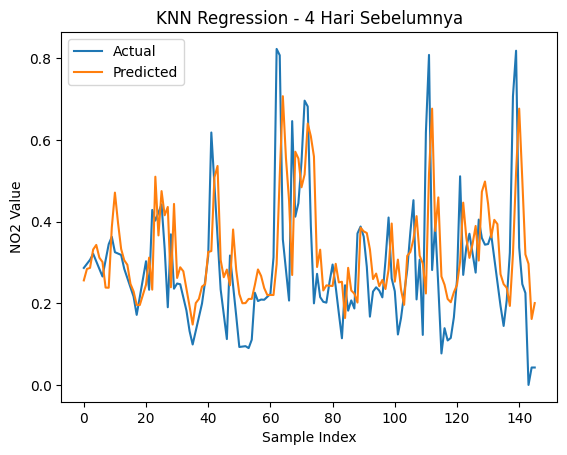

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

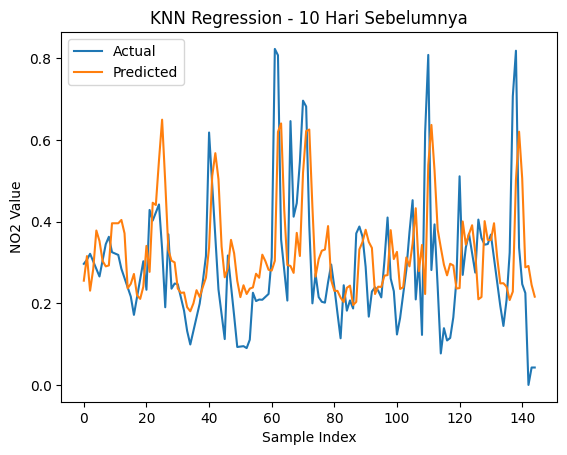

In [35]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

30 hari sebelum:

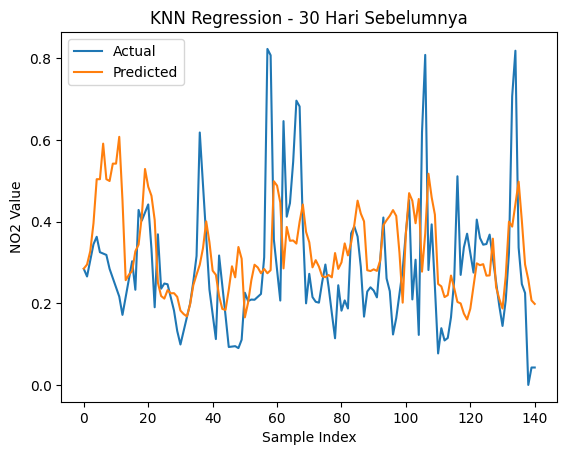

In [36]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Dari grafik hasil prediksi terlihat bahwa model dengan 4 hari sebelumnya mampu mengikuti pola data aktual lebih baik dibandingkan model dengan 10 hari dan 30 hari sebelumnya. Hal ini sesuai dengan hasil evaluasi yang menunjukkan bahwa model 4 hari sebelumnya memiliki performa terbaik pada dataset NO₂ Bangkalan.